# E42 · xarray foundations for posteriors: dims, coords, broadcasting and time

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Capital Bikeshare, Washington DC: hourly rentals for 2011-2012 (17,379 hours) with weather and calendar |
| **You will learn** | A table -> a labelled `Dataset` (`set_index` + `to_xarray`, non-dimension coords, `set_xindex`) · `stack`/`dropna` into model rows and back with a `MultiIndex` · the `DataTree`: groups, thinning every group at once, `az.extract`, `to_dataframe` · **broadcasting by name** for counterfactual grids and contrasts · `xr.apply_ufunc` to lift a NumPy RNG · `resample`, `rolling`, `coarsen`, `cumulative`, `groupby("date.month")` and `.where` on posterior predictive **draws** · binning with `BinGrouper` / `groupby_bins` and multi-key `groupby` · vectorised `.sel` for new-day predictions and `xr.concat` over a `model` dim to check coverage at day/week/month scale · heatmaps of the mean *and* of the uncertainty, a polar clock, a fan chart and a calendar of surprise |

A posterior from PyMC is not a NumPy array; it is a tree of xarray objects whose axes have
**names** (`chain`, `draw`, `hour`, `daytype`) and whose positions have **labels**
(`hour=8`, `daytype="workday"`). Most of the pain people report with Bayesian
post-processing - broadcasting errors, the wrong axis averaged, a quantile of means where a
mean of quantiles was meant - disappears once you stop thinking in axis numbers.

This notebook fits one modest count model to bike-share rentals and then spends most of its
time on what comes after the sampler: turning the posterior into the answers a planner would
ask for (how many bikes at 8 am on a warm workday? how many in July, with honest
uncertainty? which days did the model not see coming?) using only operations by name.
Siblings: E43 transforms posteriors with coords (ranks, re-indexing, `apply_ufunc`), E44 is a
gallery of plots built from labelled arrays.

In [1]:
import warnings

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr
from matplotlib.colors import LogNorm
from xarray.groupers import BinGrouper, UniqueGrouper

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
xr.set_options(display_expand_data=False, display_expand_attrs=False)
# Hours with no record are NaN in every draw, so quantiles / sds over draws there are all-NaN
# by design; and xarray's FacetGrid calls tight_layout under ArviZ's constrained layout.
warnings.filterwarnings("ignore", "All-NaN slice|Degrees of freedom", RuntimeWarning)
warnings.filterwarnings("ignore", "The figure layout has changed to tight", UserWarning)

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8a86"
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
WEATHER = ["clear", "mist", "rain/snow"]
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, xarray {xr.__version__}")


def numeric_weekday(da: xr.DataArray) -> xr.DataArray:
    """xarray's 2-D plots need numeric coords: Mon..Sun -> 0..6 (label the ticks afterwards)."""
    return da.sel(weekday=DOW).assign_coords(weekday=np.arange(7))

PyMC 6.3.2, ArviZ 1.3.0, xarray 2026.7.0


## 1 · From a table to a labelled `Dataset`

The UCI file has one row per (date, hour) with the count of rentals, weather and calendar
columns. Temperature is stored normalised; the documentation says `temp = (t + 8) / 47`,
so we convert back to degrees Celsius. Weather category 4 ("heavy rain, ice pellets") occurs
three times in two years, so we merge it into category 3.

In [2]:
data.describe("bike_hour")
df = data.load("bike_hour")
df["weather"] = np.array(WEATHER)[np.minimum(df.weathersit, 3) - 1]
df["temp_c"] = df.temp * 47 - 8
df[["dteday", "hr", "cnt", "casual", "registered", "temp_c", "hum", "weather"]].head()

bike_hour: Hourly rental counts 2011-2012 with weather and calendar covariates.
  source: Fanaee-T & Gama (2013), Capital Bikeshare (Washington DC), UCI ML Repository.
  url:    https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip


,dteday,hr,cnt,casual,registered,temp_c,hum,weather
0,2011-01-01,0,16,3,13,3.28,0.81,clear
1,2011-01-01,1,40,8,32,2.34,0.80,clear
2,2011-01-01,2,32,5,27,2.34,0.80,clear
3,2011-01-01,3,13,3,10,3.28,0.75,clear
4,2011-01-01,4,1,0,1,3.28,0.75,clear


The whole reshaping step is one line: make `(date, hour)` the pandas index and call
`to_xarray()`. Each column becomes a variable on a `date x hour` grid. Pandas has already
done the join, so every (date, hour) that is *not* in the file becomes NaN.

In [3]:
ds = (
    df.rename(columns={"dteday": "date", "hr": "hour"})
    .set_index(["date", "hour"])[["cnt", "casual", "registered", "temp_c", "hum", "weather"]]
    .to_xarray()
)
ds

<xarray.Dataset> Size: 848kB
Dimensions:     (date: 731, hour: 24)
Coordinates:
  * date        (date) datetime64[us] 6kB 2011-01-01 2011-01-02 ... 2012-12-31
  * hour        (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23
Data variables:
    cnt         (date, hour) float64 140kB 16.0 40.0 32.0 ... 90.0 61.0 49.0
    casual      (date, hour) float64 140kB 3.0 8.0 5.0 3.0 ... 8.0 7.0 13.0 12.0
    registered  (date, hour) float64 140kB 13.0 32.0 27.0 ... 83.0 48.0 37.0
    temp_c      (date, hour) float64 140kB 3.28 2.34 2.34 ... 4.22 4.22 4.22
    hum         (date, hour) float64 140kB 0.81 0.8 0.8 0.75 ... 0.6 0.56 0.65
    weather     (date, hour) object 140kB 'clear' 'clear' ... 'clear' 'clear'

Which hours are missing? The file only has rows for hours with at least one rental, so a
missing 4 am is (almost always) a zero. A few days are gaps in the record instead: a winter
storm in late January 2011, Hurricane Irene (28 August 2011) and Hurricane Sandy (29-30
October 2012), when the system was shut down.

In [4]:
print("missing hours by hour of day:")
print(ds.cnt.isnull().sum("date").to_series().to_dict())
n_hours = ds.cnt.notnull().sum("hour")
print("\ndays with fewer than 18 recorded hours:")
print(n_hours.where(n_hours < 18, drop=True).to_series())

missing hours by hour of day:
{0: 5, 1: 7, 2: 16, 3: 34, 4: 34, 5: 14, 6: 6, 7: 4, 8: 4, 9: 4, 10: 4, 11: 4, 12: 3, 13: 2, 14: 2, 15: 2, 16: 1, 17: 1, 18: 3, 19: 3, 20: 3, 21: 3, 22: 3, 23: 3}

days with fewer than 18 recorded hours:
date
2011-01-18    12.0
2011-01-26    16.0
2011-01-27     8.0
2011-08-28    17.0
2012-10-29     1.0
2012-10-30    11.0
Name: cnt, dtype: float64


Now the step that makes everything downstream easy: attach day-level information as
**non-dimension coordinates** on `date`. They ride along with every selection, reduction
and reshape, and any of them can be used to group by later. Nothing here is a new axis.

In [5]:
days = df.groupby("dteday")[["workingday", "holiday"]].first()
date_index = ds.indexes["date"]
assert (days.index == date_index).all()

ds = ds.assign_coords(
    weekday=("date", np.array(DOW)[date_index.dayofweek]),
    workingday=("date", days.workingday.to_numpy()),
    holiday=("date", days.holiday.to_numpy()),
    daytype=("date", np.where(days.workingday.to_numpy() == 1, "workday", "off day")),
    t_years=("date", (date_index - date_index[0]).days.to_numpy() / 365.25),
)
ds.coords

Coordinates:
  * date        (date) datetime64[us] 6kB 2011-01-01 2011-01-02 ... 2012-12-31
    weekday     (date) <U3 9kB 'Sat' 'Sun' 'Mon' 'Tue' ... 'Sat' 'Sun' 'Mon'
    workingday  (date) int64 6kB 0 0 1 1 1 1 1 0 0 1 1 ... 1 0 0 1 0 1 1 1 0 0 1
    holiday     (date) int64 6kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 1 0 0 0 0 0 0
    daytype     (date) <U7 20kB 'off day' 'off day' ... 'off day' 'workday'
    t_years     (date) float64 6kB 0.0 0.002738 0.005476 ... 1.993 1.996 1.999
  * hour        (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23

Selection by label now reads like the question. Dates accept partial strings; a
non-dimension coord can be used in a boolean `.where`, or promoted to an index with
`set_xindex` so that `.sel` works on it directly.

In [6]:
july_8am = ds.cnt.sel(date="2012-07", hour=8)
print(f"mean rentals at 8 am in July 2012: {float(july_8am.mean()):.0f}")

sat = ds.cnt.where(ds.weekday == "Sat")  # keeps the shape, NaN elsewhere
print(f"mean hourly rentals on Saturdays: {float(sat.mean()):.0f}")

by_weekday = ds.set_xindex("weekday")  # an index on a non-dimension coordinate
print("Saturdays via .sel:", by_weekday.sel(weekday="Sat").sizes["date"])

mean rentals at 8 am in July 2012: 500
mean hourly rentals on Saturdays: 190
Saturdays via .sel: 105


Two years of data in one image. xarray's `.plot` knows the axes from the names, so the
left panel is the whole dataset (731 days x 24 hours) and the right is a `groupby` on the
`weekday` coordinate. Two small wrinkles: `groupby` sorts group labels alphabetically (Fri,
Mon, Sat, ...), so we reorder with `.sel(weekday=DOW)`; and xarray's 2-D plots refuse string
coordinates, so `numeric_weekday` swaps in 0-6 for plotting and puts the names back as ticks.

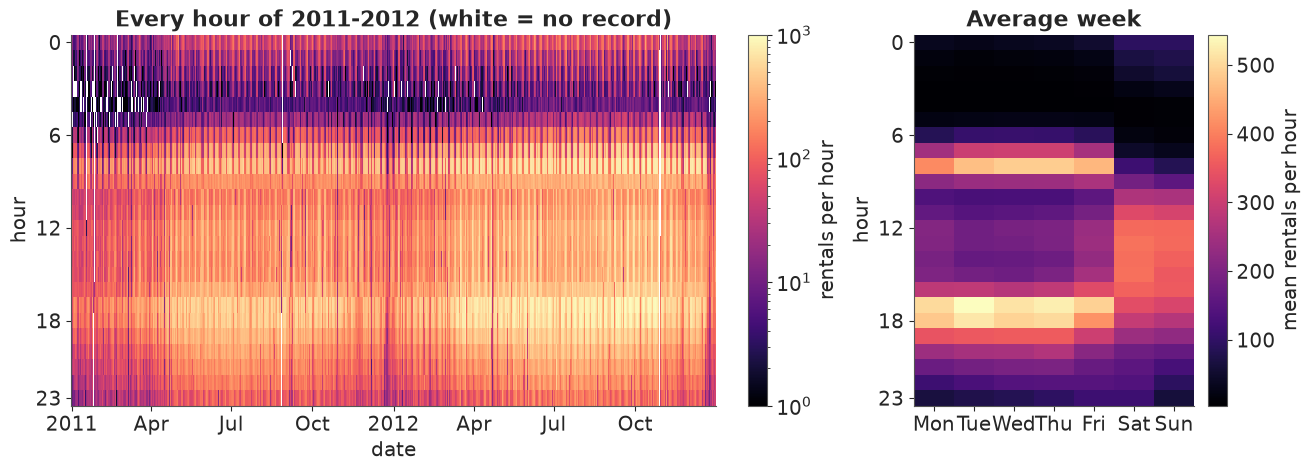

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), width_ratios=[2.3, 1])
ds.cnt.plot(
    x="date", y="hour", ax=axes[0], norm=LogNorm(1, 1000), cmap="magma", yincrease=False,
    cbar_kwargs={"label": "rentals per hour"},
)
axes[0].set(title="Every hour of 2011-2012 (white = no record)", yticks=[0, 6, 12, 18, 23])
numeric_weekday(ds.cnt.groupby("weekday").mean()).plot(
    x="weekday", y="hour", ax=axes[1], cmap="magma", yincrease=False,
    cbar_kwargs={"label": "mean rentals per hour"},
)
axes[1].set(title="Average week", yticks=[0, 6, 12, 18, 23], xlabel="")
axes[1].set_xticks(range(7), DOW);

Two regimes jump out: workdays have two commuter spikes (8 am, 5-6 pm), weekends one broad
afternoon hump; 2012 is visibly brighter than 2011 (the system was growing), summers
brighter than winters, and the white vertical stripes are the gaps listed above.

## 2 · A modest model with named dimensions

The model is a vehicle, so it is kept small. Rentals in hour $h$ of date $d$:

$$
\begin{aligned}
y_{dh} &\sim \text{NegBinomial}(\mu_{dh}, \alpha) \\
\log \mu_{dh} &= a_{k} + \text{profile}_{k,h} + \beta_{k} T_{dh} + \gamma_{k} T_{dh}^2
    + w_{\text{weather}_{dh}} + \tau \, t_d
\end{aligned}
$$

where $k$ is the day type (workday or off day), $T = (\text{temp} - 15\,°C)/10$, $w$ is a
sum-to-zero weather effect and $t_d$ is time in years (the system grew). The hour-of-day
profile is a `ZeroSumNormal` over hours within each day type.

The data are a `date x hour` grid with holes; the likelihood wants a flat list of recorded
hours. `stack` makes the rows (a `MultiIndex` of (date, hour)) and `dropna` removes the holes.
Every covariate, including the day-level coords, comes along for free.

In [8]:
rows = ds.stack(obs=("date", "hour")).dropna("obs", subset=["cnt"])
print(rows.sizes, rows.indexes["obs"][:3].tolist(), sep="\n")

DAYTYPES = ["workday", "off day"]
daytype_idx = pd.Index(DAYTYPES).get_indexer(rows.daytype.values)
weather_idx = pd.Index(WEATHER).get_indexer(rows.weather.values)
assert (daytype_idx >= 0).all() and (weather_idx >= 0).all()

coords = {
    "daytype": DAYTYPES, "hour": np.arange(24), "weather": WEATHER,
    "obs": np.arange(rows.sizes["obs"]),
}
T_rows = (rows.temp_c.values - 15) / 10

with pm.Model(coords=coords) as model:
    a = pm.Normal("a", 5, 1.5, dims="daytype")
    profile = pm.ZeroSumNormal("profile", sigma=1.5, dims=("daytype", "hour"), n_zerosum_axes=1)
    b_temp = pm.Normal("b_temp", 0, 0.5, dims="daytype")
    b_temp2 = pm.Normal("b_temp2", 0, 0.5, dims="daytype")
    weather_eff = pm.ZeroSumNormal("weather_eff", sigma=0.5, dims="weather")
    trend = pm.Normal("trend", 0, 0.5)
    alpha = pm.Gamma("alpha", 2, 0.2)

    eta = (
        a[daytype_idx] + profile[daytype_idx, rows.hour.values]
        + b_temp[daytype_idx] * T_rows + b_temp2[daytype_idx] * T_rows**2
        + weather_eff[weather_idx] + trend * rows.t_years.values
    )
    pm.NegativeBinomial(
        "cnt", mu=pm.math.exp(eta), alpha=alpha, observed=rows.cnt.values.astype(int), dims="obs"
    )

model

Frozen({'obs': 17379})
[(Timestamp('2011-01-01 00:00:00'), 0), (Timestamp('2011-01-01 00:00:00'), 1), (Timestamp('2011-01-01 00:00:00'), 2)]


Priors: `a ~ Normal(5, 1.5)` puts the baseline between roughly 10 and 3000 rentals an hour;
a 10 °C change multiplying rentals by more than $e^{1} \approx 2.7$ is already unlikely
under `Normal(0, 0.5)`. With 17k rows the likelihood dominates all of these; we skip the
prior predictive check here (E01 shows it) and go straight to sampling.

In [9]:
with model:
    idata = pm.sample(random_seed=RANDOM_SEED)

summ = az.summary(idata, round_to=4)
print(
    f"nutpie, {idata.posterior.attrs['tuning_steps']} tuning steps; "
    f"max r_hat {summ.r_hat.max():.3f}, min bulk ESS {summ.ess_bulk.min():.0f}, "
    f"min tail ESS {summ.ess_tail.min():.0f}, "
    f"divergences {int(idata.sample_stats['diverging'].sum())}"
)
az.summary(idata, var_names=["a", "b_temp", "b_temp2", "weather_eff", "trend", "alpha"],
           round_to=3)

NUTS[nutpie]: [a, profile, b_temp, b_temp2, weather_eff, trend, alpha]


nutpie, 400 tuning steps; max r_hat 1.006, min bulk ESS 915, min tail ESS 1578, divergences 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a[workday],4.081,0.007,4.069,4.093,915.453,1577.902,1.005,0.000,0.000
a[off day],4.181,0.009,4.166,4.195,1193.670,1712.584,1.006,0.000,0.000
b_temp[workday],0.318,0.004,0.311,0.324,5176.097,3269.444,1.000,0.000,0.000
b_temp[off day],0.421,0.005,0.412,0.430,5245.245,2776.211,1.001,0.000,0.000
b_temp2[workday],-0.127,0.004,-0.133,-0.120,2530.283,2431.321,1.002,0.000,0.000
b_temp2[off day],-0.175,0.006,-0.184,-0.166,2919.273,2759.055,1.000,0.000,0.000
weather_eff[clear],0.229,0.004,0.222,0.236,2471.431,2589.775,1.002,0.000,0.000
weather_eff[mist],0.128,0.005,0.121,0.136,3442.856,3187.043,1.001,0.000,0.000
weather_eff[rain/snow],-0.357,0.007,-0.368,-0.347,1931.578,2580.384,1.003,0.000,0.000
trend,0.435,0.005,0.427,0.443,1085.557,1858.918,1.003,0.000,0.000


Clean: all r_hat at 1.00-1.01, at least ~900 effective draws, no divergences. The trend of
about 0.44 per year means rentals grew by a factor of $e^{0.44} \approx 1.55$ a year at
fixed weather and temperature. The rest of the notebook is about using this posterior.

## 3 · The `DataTree`: groups, names and the sample dimension

`pm.sample` returns an `xr.DataTree`. Each child is a `Dataset` whose variables share the
`chain` and `draw` dimensions plus the model's own dims.

In [10]:
print(list(idata.children))
idata.posterior

['posterior', 'sample_stats', 'constant_data', 'observed_data']


<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:      (chain: 4, draw: 1000, daytype: 2, hour: 24, weather: 3)
    Coordinates:
      * chain        (chain) int64 32B 0 1 2 3
      * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
      * daytype      (daytype) object 16B 'workday' 'off day'
      * hour         (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23
      * weather      (weather) object 24B 'clear' 'mist' 'rain/snow'
    Data variables:
        a            (chain, draw, daytype) float64 64kB 4.076 4.177 ... 4.082 4.188
        b_temp       (chain, draw, daytype) float64 64kB 0.3231 0.4165 ... 0.421
        b_temp2      (chain, draw, daytype) float64 64kB -0.1269 -0.1741 ... -0.1844
        trend        (chain, draw) float64 32kB 0.4375 0.4395 0.436 ... 0.431 0.4376
        profile      (chain, draw, daytype, hour) float64 2MB -1.056 ... -0.2541
        weather_eff  (chain, draw, weather) float64 96kB 0.2337 0.1303 ... -0.3547
        alpha        (chain, draw) float64 32kB 9.559 9.532 9.707 ... 9.66 9.813
    Attributes: (9)

**The one before/after in this notebook.** The positional way needs you to remember the axis
order `(chain, draw, daytype, hour)` and which integer means "workday". Add a dimension to the
model next month (say `year`) and the first line silently computes something else; the
second keeps meaning what it says.

In [11]:
prof = idata.posterior["profile"]
positional = prof.values[:, :, 0, 8].mean()  # before: which axis is which? is 0 "workday"?
named = prof.sel(daytype="workday", hour=8).mean(("chain", "draw"))  # after
print(f"{positional:.4f} == {float(named):.4f}")

1.5982 == 1.5982


Operations on the tree apply to every group that has the dimension. Thinning with `isel`
thins `posterior` and `sample_stats` together (keeping the `draw` labels, so draw 10 is
still draw 10), and leaves `observed_data` alone.

In [12]:
thin = idata.isel(draw=slice(None, None, 10))
for name, node in thin.children.items():
    print(f"{name:14s}", dict(node.sizes))
print("kept draw labels:", thin.posterior.draw.values[:5])

posterior      {'chain': 4, 'draw': 100, 'daytype': 2, 'hour': 24, 'weather': 3}
sample_stats   {'chain': 4, 'draw': 100}
constant_data  {}
observed_data  {'obs': 17379}
kept draw labels: [ 0 10 20 30 40]


Most summaries do not care which chain a draw came from. `az.extract` stacks `chain` and
`draw` into one `sample` dimension (a `MultiIndex`, so nothing is lost) and returns a plain
`Dataset`; `.unstack("sample")` goes back. We will use `post` for all posterior arithmetic.

In [13]:
post = az.extract(idata)
print(dict(post.sizes))
print(post.indexes["sample"][:3].tolist())
print("unstacked:", post["profile"].unstack("sample").dims)

{'daytype': 2, 'sample': 4000, 'hour': 24, 'weather': 3}
[(0, 0), (0, 1), (0, 2)]
unstacked: ('daytype', 'hour', 'chain', 'draw')


And when a tidy-data tool is the right one, `to_dataframe()` gives one row per labelled
cell with the dims as the index. Here: the multiplicative weather effects relative to the
average weather, as a small table.

In [14]:
tidy = np.exp(idata.posterior["weather_eff"]).to_dataframe().reset_index()
print(tidy.head(3))
tidy.groupby("weather")["weather_eff"].quantile([0.05, 0.5, 0.95]).unstack().round(3)

   chain  draw    weather  weather_eff
0      0     0      clear     1.263241
1      0     0       mist     1.139122
2      0     0  rain/snow     0.694934


,0.05,0.50,0.95
weather,,,
clear,1.249,1.257,1.266
mist,1.128,1.137,1.146
rain/snow,0.692,0.700,0.707


### Posterior predictive draws, back on the calendar

`sample_posterior_predictive` returns draws on the model's flat `obs` dimension. We saved
the `MultiIndex` of those rows when we stacked, so putting the draws back on the
`date x hour` grid is `assign_coords` + `unstack`. We use the thinned tree (400 draws):
17k rows x 4000 draws would be 560 MB of integers, and 400 draws are plenty for predictive
summaries.

In [15]:
with model:
    pp = pm.sample_posterior_predictive(thin, random_seed=RANDOM_SEED)

obs_mi = xr.Coordinates.from_pandas_multiindex(rows.indexes["obs"], "obs")
yrep = (
    pp.posterior_predictive["cnt"]
    .assign_coords(obs_mi)  # obs: 0..17378  ->  obs: (date, hour)
    .unstack("obs")  # -> (chain, draw, date, hour), NaN where no record
    .stack(sample=("chain", "draw"))
    .transpose("sample", "date", "hour")
    .assign_coords({k: ds[k] for k in ["weekday", "workingday", "holiday", "daytype"]})
)
del pp
yrep

Sampling: [cnt]


<xarray.DataArray 'cnt' (sample: 400, date: 731, hour: 24)> Size: 56MB
43.0 29.0 5.0 12.0 0.0 3.0 6.0 ... 406.0 363.0 266.0 117.0 259.0 210.0 123.0
Coordinates:
  * sample      (sample) object 3kB MultiIndex
  * chain       (sample) int64 3kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3
  * draw        (sample) int64 3kB 0 10 20 30 40 50 ... 940 950 960 970 980 990
  * date        (date) datetime64[us] 6kB 2011-01-01 2011-01-02 ... 2012-12-31
    weekday     (date) <U3 9kB 'Sat' 'Sun' 'Mon' 'Tue' ... 'Sat' 'Sun' 'Mon'
    workingday  (date) int64 6kB 0 0 1 1 1 1 1 0 0 1 1 ... 1 0 0 1 0 1 1 1 0 0 1
    holiday     (date) int64 6kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 1 0 0 0 0 0 0
    daytype     (date) <U7 20kB 'off day' 'off day' ... 'off day' 'workday'
    t_years     (date) float64 6kB 0.0 0.002738 0.005476 ... 1.993 1.996 1.999
  * hour        (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23

`yrep` has NaN exactly where the data have no record, so any comparison of `yrep` with
`ds.cnt` is automatically like with like.

## 4 · Broadcasting by name: counterfactual grids without loops

A planner asks: *how many bikes will be taken each hour on a clear day, as a function of
temperature, on a workday versus an off day?* The posterior mean function is a formula in
the parameters; to evaluate it on a grid we make the grid a set of **named** arrays and write
the formula. xarray aligns dimensions by name and broadcasts the rest: `a` has `(daytype,
sample)`, `profile` has `(daytype, hour, sample)`, the temperature grid has `(temp_c,)`, and
the result has all four. No `reshape`, no `np.newaxis`, no loop.

In [16]:
temp_grid = xr.DataArray(np.arange(-5.0, 36.0), dims="temp_c", name="temp_c")
temp_grid = temp_grid.assign_coords(temp_c=temp_grid)
T = (temp_grid - 15) / 10
t_mid2012 = 1.5  # years since 2011-01-01: fix the growth trend at mid-2012

log_mu = (
    post["a"] + post["profile"] + post["b_temp"] * T + post["b_temp2"] * T**2
    + post["weather_eff"].sel(weather="clear", drop=True) + post["trend"] * t_mid2012
)
mu = np.exp(log_mu).rename("mu")
print(mu.dims, f"{mu.nbytes / 1e6:.0f} MB")

('daytype', 'sample', 'hour', 'temp_c') 63 MB


`mu` is 63 MB of posterior mean functions: one for each of the 4000 draws at each of
2 x 24 x 41 grid points. Its posterior mean is a two-panel heatmap straight from xarray's
`FacetGrid` (`col="daytype"`).

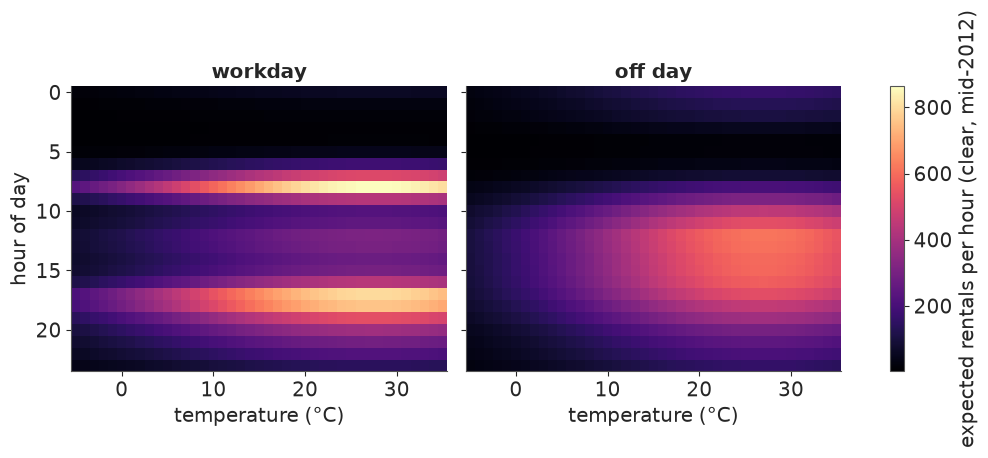

In [17]:
fg = mu.mean("sample").plot(
    x="temp_c", y="hour", col="daytype", cmap="magma", yincrease=False, size=4, aspect=1.2,
    cbar_kwargs={"label": "expected rentals per hour (clear, mid-2012)"},
)
fg.set_axis_labels("temperature (°C)", "hour of day")
fg.set_titles("{value}");

Workdays are a two-spike day at every temperature; off days one broad afternoon block that
lights up more strongly with warmth. Both peak around 27 °C and ease off above that (the
quadratic term). This is the model's view of mid-2012 on a clear day; any other
scenario is one `.sel` or one number away.

**Contrasts are subtraction of selections.** Workday minus off day leaves `(hour, temp_c,
sample)`; we pick three temperatures and summarise over `sample` with `.quantile`, which
adds a `quantile` dimension we can select from when plotting.

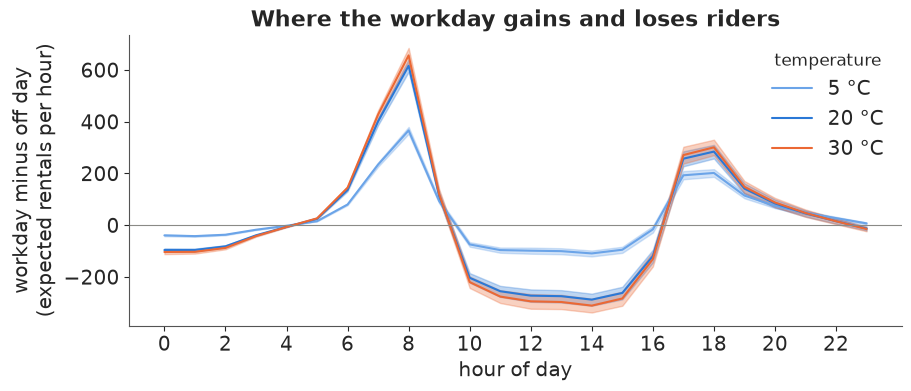

In [18]:
contrast = mu.sel(daytype="workday") - mu.sel(daytype="off day")
c_q = contrast.sel(temp_c=[5.0, 20.0, 30.0]).quantile([0.03, 0.5, 0.97], dim="sample")

fig, ax = plt.subplots(figsize=(9, 3.8))
for temp_c, color in zip(c_q.temp_c.values, ["#6ba4e8", BLUE, ORANGE]):
    q = c_q.sel(temp_c=temp_c)
    ax.fill_between(q.hour, q.sel(quantile=0.03), q.sel(quantile=0.97), color=color, alpha=0.3)
    ax.plot(q.hour, q.sel(quantile=0.5), color=color, label=f"{temp_c:.0f} °C")
ax.axhline(0, color=GREY, lw=0.8)
ax.set(xlabel="hour of day", ylabel="workday minus off day\n(expected rentals per hour)",
       xticks=range(0, 24, 2), title="Where the workday gains and loses riders")
ax.legend(title="temperature");

At 20-30 °C a workday adds about 600 riders at 8 am and about 300 at 5-6 pm, and loses
200-300 an hour from 10 am to 3 pm (a warm weekend afternoon is the leisure peak). At 5 °C
every one of those differences shrinks, because cold scales all hours down together.
The 94% bands are barely wider than the lines:
with 17k hourly counts, the *mean function* is pinned down tightly. The uncertainty that
matters to a planner is predictive - how many bikes will actually be taken - which is next.

### A predictive clock: lifting a NumPy RNG with `apply_ufunc`

`numpy.random.Generator.negative_binomial` knows nothing about names, but `xr.apply_ufunc`
will broadcast its labelled inputs by name, call the function on the aligned arrays and
put the labels back on. That gives predictive draws on the grid with one call (using the
NegBinomial's `n = alpha`, `p = alpha / (alpha + mu)` parameterisation).

In [19]:
mu20 = mu.sel(temp_c=20.0)
ytilde = xr.apply_ufunc(
    rng.negative_binomial, post["alpha"], post["alpha"] / (post["alpha"] + mu20)
).rename("rentals")
bands = ytilde.quantile([0.05, 0.25, 0.5, 0.75, 0.95], dim="sample")
print(ytilde.dims)
print("workday 5 pm, 20 °C:", bands.sel(daytype="workday", hour=17).round().values)

('sample', 'daytype', 'hour')
workday 5 pm, 20 °C: [ 398.  572.  718.  889. 1177.]


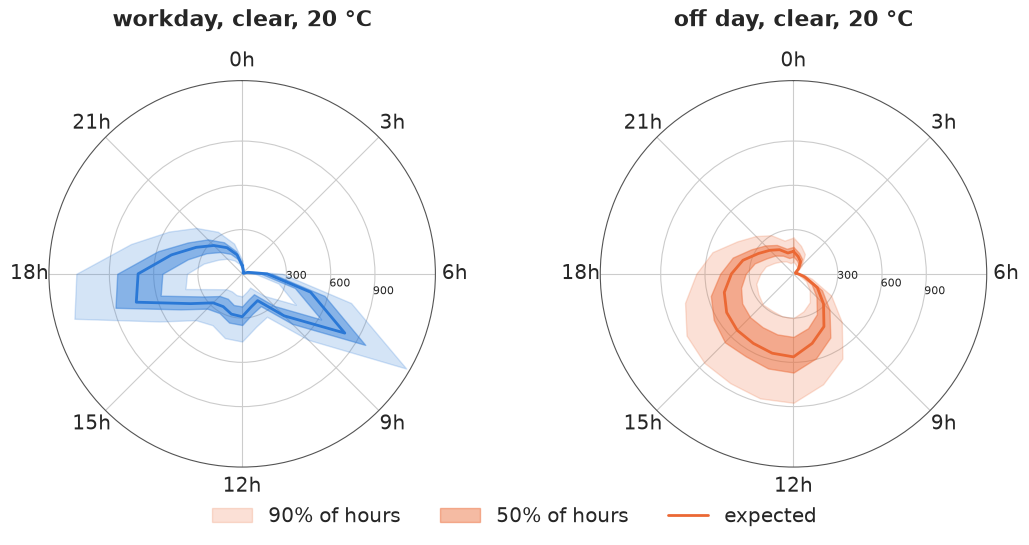

In [20]:
theta = 2 * np.pi * (np.arange(25) % 24) / 24  # close the circle: hour 0 again at the end

fig, axes = plt.subplots(1, 2, figsize=(11, 5.4), subplot_kw={"projection": "polar"})
for ax, daytype, color in zip(axes, DAYTYPES, [BLUE, ORANGE]):
    b = bands.sel(daytype=daytype).isel(hour=np.arange(25) % 24)
    ax.fill_between(theta, b.sel(quantile=0.05), b.sel(quantile=0.95), color=color, alpha=0.2,
                    label="90% of hours")
    ax.fill_between(theta, b.sel(quantile=0.25), b.sel(quantile=0.75), color=color, alpha=0.45,
                    label="50% of hours")
    ax.plot(theta, mu20.sel(daytype=daytype).mean("sample").isel(hour=np.arange(25) % 24),
            color=color, lw=2, label="expected")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(2 * np.pi * np.arange(0, 24, 3) / 24, [f"{h}h" for h in range(0, 24, 3)])
    ax.set_rlim(0, 1.02 * float(bands.max()))
    ax.set_rticks([300, 600, 900], ["300", "600", "900"], fontsize=8)
    ax.set_rlabel_position(100)
    ax.set_title(f"{daytype}, clear, 20 °C", pad=18)
fig.legend(*axes[1].get_legend_handles_labels(), loc="outside lower center", ncols=3);

Read it like a clock face: midnight at the top, noon at the bottom. The workday clock has
two lobes pointing at 8 am and 5-6 pm; the off-day clock one fat lobe over the afternoon.
The bands are *hours*, not parameters: at 5 pm on a clear 20 °C workday the median is about
720 rentals, half of such hours see 570-890 and one in ten falls outside 400-1180. That spread
is the NegBinomial overdispersion; the posterior of the mean is a thin line inside it. (Section
6 will show this single overdispersion parameter is standing in for something else.)

## 5 · Time machinery on posterior predictive draws

Planners want totals: per week, per month, per season. The rule that makes this correct:
**aggregate the draws, then summarise.** A quantile of a sum is not the sum of quantiles.
Because every draw is a complete replicated history, `yrep.sum("hour")` is a posterior
predictive draw of *daily* totals, and every time operation xarray has works on it.

First, daily totals and a demonstration of the rule with weekly totals via `resample`.

In [21]:
obs_day = ds.cnt.sum("hour")  # missing hours count as 0 in both: like for like
rep_day = yrep.sum("hour")

rep_week = rep_day.resample(date="W").sum()  # weekly totals, per draw
right = rep_week.quantile([0.05, 0.95], dim="sample")
wrong = rep_day.quantile([0.05, 0.95], dim="sample").resample(date="W").sum()
width = lambda q: q.sel(quantile=0.95) - q.sel(quantile=0.05)  # noqa: E731
print(f"weeks: {rep_week.sizes['date']}, labelled by the Sunday that ends them:",
      rep_week.date.values[:2].astype("datetime64[D]"))
print(f"median 90% width, draws summed first:      {float(width(right).median()):,.0f}")
print(f"median 90% width, daily quantiles summed:  {float(width(wrong).median()):,.0f}  (wrong)")

weeks: 106, labelled by the Sunday that ends them:

 ['2011-01-02' '2011-01-09']
median 90% width, draws summed first:      3,301
median 90% width, daily quantiles summed:  8,510  (wrong)


Summing daily quantiles gives intervals several times too wide: it assumes every day of
the week is simultaneously at its own 5th percentile, which the model says almost never
happens. Aggregating draws keeps whatever dependence the model has between days - here,
given the parameters, days are independent, so the errors partly cancel. Whether days really
*are* independent is a modelling claim, and section 6 checks it.

`coarsen` is the index-agnostic cousin of `resample`: fixed blocks of 7 *rows* starting at
the first date (a Saturday), labelled by the block's centre date. Different weeks, same
totals-per-block logic - choose `resample` when the calendar matters. One trap: `coarsen`
also averages every non-dimension coordinate along `date` (`coord_func="mean"`), which raises
a `TypeError` on string coords such as `weekday`, so drop (or give a `coord_func` for) them.

In [22]:
blocks = obs_day.drop_vars(["weekday", "daytype"]).coarsen(date=7, boundary="trim").sum()
print("coarsen labels:", blocks.date.values[:2].astype("datetime64[D]"),
      "| resample labels:", rep_week.date.values[:2].astype("datetime64[D]"))

coarsen labels: ['2011-01-04' '2011-01-11'] | resample labels: ['2011-01-02' '2011-01-09']


### A fan chart of monthly totals, and a rolling view

`resample(date="MS")` gives monthly totals per draw; `.quantile` with five levels gives a
`quantile` dimension, i.e. a fan. On the right, a 7-day centred `rolling` mean, again per
draw first, for 2012.

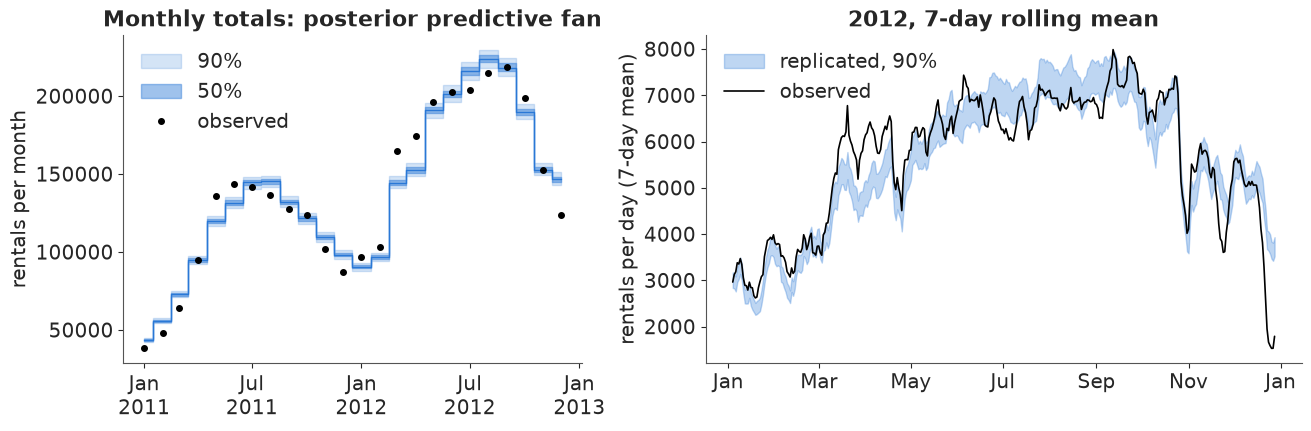

In [23]:
rep_month = rep_day.resample(date="MS").sum()
obs_month = obs_day.resample(date="MS").sum()
fan = rep_month.quantile([0.05, 0.25, 0.5, 0.75, 0.95], dim="sample")

rep_roll = rep_day.sel(date="2012").rolling(date=7, center=True).mean()
obs_roll = obs_day.sel(date="2012").rolling(date=7, center=True).mean()
roll_q = rep_roll.quantile([0.05, 0.95], dim="sample")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), width_ratios=[1, 1.3])
ax = axes[0]
x = fan.date.values
ax.fill_between(x, fan.sel(quantile=0.05), fan.sel(quantile=0.95), color=BLUE, alpha=0.2,
                step="mid", label="90%")
ax.fill_between(x, fan.sel(quantile=0.25), fan.sel(quantile=0.75), color=BLUE, alpha=0.45,
                step="mid", label="50%")
ax.plot(x, fan.sel(quantile=0.5), color=BLUE, drawstyle="steps-mid", lw=1)
ax.plot(x, obs_month, "o", color="k", ms=4, label="observed")
ax.set(ylabel="rentals per month", title="Monthly totals: posterior predictive fan")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.legend(loc="upper left")

ax = axes[1]
ax.fill_between(roll_q.date, roll_q.sel(quantile=0.05), roll_q.sel(quantile=0.95), color=BLUE,
                alpha=0.3, label="replicated, 90%")
ax.plot(obs_roll.date, obs_roll, color="k", lw=1.2, label="observed")
ax.set(ylabel="rentals per day (7-day mean)", title="2012, 7-day rolling mean")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left");

The xarray part worked; the model did not pass this check. The monthly bands are only a
few percent wide, yet most observed months fall outside them: spring (April-June 2011,
March-April 2012) runs well above the fan and December 2012 far below it. The rolling view
says why: the observed line leaves the band for *weeks* at a time - a warm-weather surge in
March 2012, the Sandy shutdown at the end of October, the Christmas collapse. Errors that
persist over days cannot cancel when we sum days, so aggregating the draws of a model
without them gives confidently wrong totals. Keep that in mind through section 6.

### `groupby("date.month")`, `cumulative` and `.where`

The virtual coordinate `"date.month"` groups by calendar month across both years. Here we
compute, per draw, how far the observed monthly mean sits from the replicated one, as a
ratio. This is a posterior *distribution* of the model's error for each calendar month.

In [24]:
ratio = obs_day.groupby("date.month").mean() / rep_day.groupby("date.month").mean()
ratio.quantile([0.05, 0.5, 0.95], dim="sample").to_pandas().T.round(3)

quantile,0.05,0.50,0.95
month,,,
1,0.984,1.006,1.028
2,0.969,0.991,1.013
3,1.031,1.053,1.073
4,1.065,1.088,1.109
5,1.047,1.069,1.087
6,1.022,1.041,1.061
7,0.937,0.956,0.977
8,0.934,0.951,0.970
9,0.968,0.988,1.007


Observed daily rentals run 4-9% above the model from March to June and 4-5% below it in
July-August, and December sits 14% below; most intervals exclude 1. Seasonality enters this
model only through temperature, so "spring enthusiasm" at a given temperature and the
holiday lull are invisible to it.

`cumulative("date").sum()` is a running total (the modern spelling of `cumsum`, with the
same API as `rolling`). Per draw, "the first date the 2012 running total reaches one
million" is `(running >= 1e6).idxmax("date")`: a posterior predictive distribution over a
**date**.

In [25]:
running = rep_day.sel(date="2012").cumulative("date").sum()
millionth = (running >= 1e6).idxmax("date")
obs_millionth = (obs_day.sel(date="2012").cumulative("date").sum() >= 1e6).idxmax("date")
print("observed:", obs_millionth.values.astype("datetime64[D]"))
print("replicated 5/50/95%:",
      pd.to_datetime(millionth.values).to_series().quantile([0.05, 0.5, 0.95]).dt.date.tolist())

observed: 2012-07-11
replicated 5/50/95%: [datetime.date(2012, 7, 17), datetime.date(2012, 7, 18), datetime.date(2012, 7, 20)]


`.where` keeps the shape and masks with NaN, so it combines with coords to carve out a
sub-population without losing alignment. What share of workday rentals happen in the four
commuter hours (7-8 am, 5-6 pm)? Per draw, then summarised:

In [26]:
commute = yrep.hour.isin([7, 8, 17, 18]) & (yrep.workingday == 1)
share_rep = yrep.where(commute).sum(("date", "hour")) / yrep.where(yrep.workingday == 1).sum(
    ("date", "hour"))
share_obs = ds.cnt.where(commute).sum() / ds.cnt.where(ds.workingday == 1).sum()
print(f"observed commuter share {float(share_obs):.3f}; replicated 90% interval "
      f"{float(share_rep.quantile(0.05)):.3f}-{float(share_rep.quantile(0.95)):.3f}")

observed commuter share 0.387; replicated 90% interval 0.386-0.396


## 6 · Calibration by bins: where does the model get it wrong?

Per recorded hour we compute three diagnostics from the 400 replicated draws, all as
labelled `date x hour` arrays:

- the (mid-)PIT, $P(y^{rep} < y) + \tfrac12 P(y^{rep} = y)$: uniform if calibrated;
- a standardised residual $z = (y - \bar y^{rep}) / \text{sd}(y^{rep})$;
- whether $y$ falls inside the central 90% predictive interval.

In [27]:
y = ds.cnt
pit = ((yrep < y).mean("sample") + 0.5 * (yrep == y).mean("sample")).where(y.notnull())
z = (y - yrep.mean("sample")) / yrep.std("sample")
q05, q95 = yrep.quantile(0.05, dim="sample"), yrep.quantile(0.95, dim="sample")
inside = ((y >= q05) & (y <= q95)).where(y.notnull())

diag = xr.Dataset({"pit": pit, "z": z, "inside90": inside}).assign_coords(
    temp_c=ds.temp_c, weather=ds.weather
)
print(f"overall 90% coverage: {float(diag.inside90.mean()):.3f}")

overall 90% coverage: 0.910


**Binning on a 2-D coordinate.** `temp_c` varies over both `date` and `hour`; `groupby` with
a `BinGrouper` flattens whatever it needs to. `groupby_bins` is the older spelling of the
same thing. The **multi-key** form takes one grouper per coordinate and returns a grid: here
hour-of-day blocks (a `BinGrouper` on the `hour` dimension, with labels) by weather.

In [28]:
temp_bins = np.arange(-10, 45, 5)
by_temp = diag.groupby(temp_c=BinGrouper(bins=temp_bins)).mean()
n_temp = diag.pit.groupby(temp_c=BinGrouper(bins=temp_bins)).count()
same = diag.z.groupby_bins("temp_c", bins=temp_bins).mean()
assert np.allclose(same.values, by_temp.z.values, equal_nan=True)

hour_blocks = BinGrouper(
    bins=[-1, 5, 9, 15, 19, 23],
    labels=["night 0-5", "am rush 6-9", "midday 10-15", "pm rush 16-19", "evening 20-23"],
)
grid = diag.groupby(hour=hour_blocks, weather=UniqueGrouper()).mean().sel(weather=WEATHER)
grid.z.to_pandas().round(2)

weather,clear,mist,rain/snow
hour_bins,,,
night 0-5,-0.02,-0.03,0.42
am rush 6-9,0.03,-0.05,-0.11
midday 10-15,-0.02,0.09,-0.22
pm rush 16-19,-0.01,-0.02,0.10
evening 20-23,0.03,-0.07,-0.09


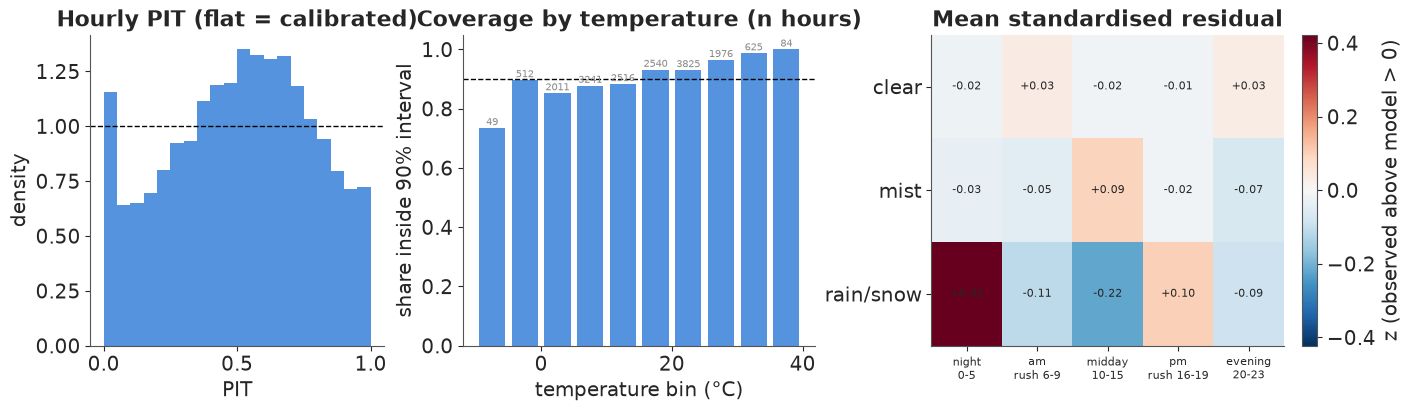

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), width_ratios=[1, 1.2, 1.2])
ax = axes[0]
ax.hist(diag.pit.values.ravel(), bins=20, range=(0, 1), color=BLUE, alpha=0.8, density=True)
ax.axhline(1, color="k", lw=1, ls="--")
ax.set(xlabel="PIT", ylabel="density", title="Hourly PIT (flat = calibrated)")

ax = axes[1]
mids = [iv.mid for iv in by_temp.temp_c_bins.values]
ax.bar(mids, by_temp.inside90, width=4, color=BLUE, alpha=0.8)
ax.axhline(0.9, color="k", ls="--", lw=1)
for m, v, n in zip(mids, by_temp.inside90.values, n_temp.values):
    ax.text(m, v + 0.01, f"{n}", ha="center", fontsize=7, color=GREY)
ax.set(xlabel="temperature bin (°C)", ylabel="share inside 90% interval", ylim=(0, 1.05),
       title="Coverage by temperature (n hours)")

ax = axes[2]
lim = float(np.abs(grid.z).max())
im = ax.imshow(grid.z.transpose("weather", "hour_bins"), cmap="RdBu_r", vmin=-lim, vmax=lim,
               aspect="auto")
ax.set_xticks(range(5), [s.replace(" ", "\n", 1) for s in grid.hour_bins.values], fontsize=8)
ax.set_yticks(range(3), WEATHER)
for (i, j), v in np.ndenumerate(grid.z.transpose("weather", "hour_bins").values):
    ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Mean standardised residual")
fig.colorbar(im, ax=ax, label="z (observed above model > 0)");

Three readings, each from one line of grouping code:

- **Hourly PIT** is far from flat: a hump in the middle (for typical hours the predictive
  distribution is *too wide*) plus a spike at 0 (hours with far fewer riders than expected).
  Both are what a missing day-level effect does: good days and bad days are pooled into one
  overdispersion parameter, which then over-covers ordinary hours and still misses bad days.
- **Coverage by temperature**: the overall 91% hides a slope, from 74-88% below 15 °C
  (the few hours below -5 °C are the worst) to 96-100% above 25 °C.
- **Hour block x weather**: clear and misty hours are fine (|z| < 0.1). Rain costs more
  riders at midday (z = -0.22) than the single multiplicative weather effect allows, and
  fewer at night (+0.42): the weather effect should depend on the hour.

### The week as a heatmap: the mean, the uncertainty, and the surprise

Three `weekday x hour` summaries from one `groupby("weekday")` on a `Dataset` of three
derived variables: what the model expects, how uncertain a single hour is (the predictive
coefficient of variation, sd / mean), and where the data disagree (mean z).

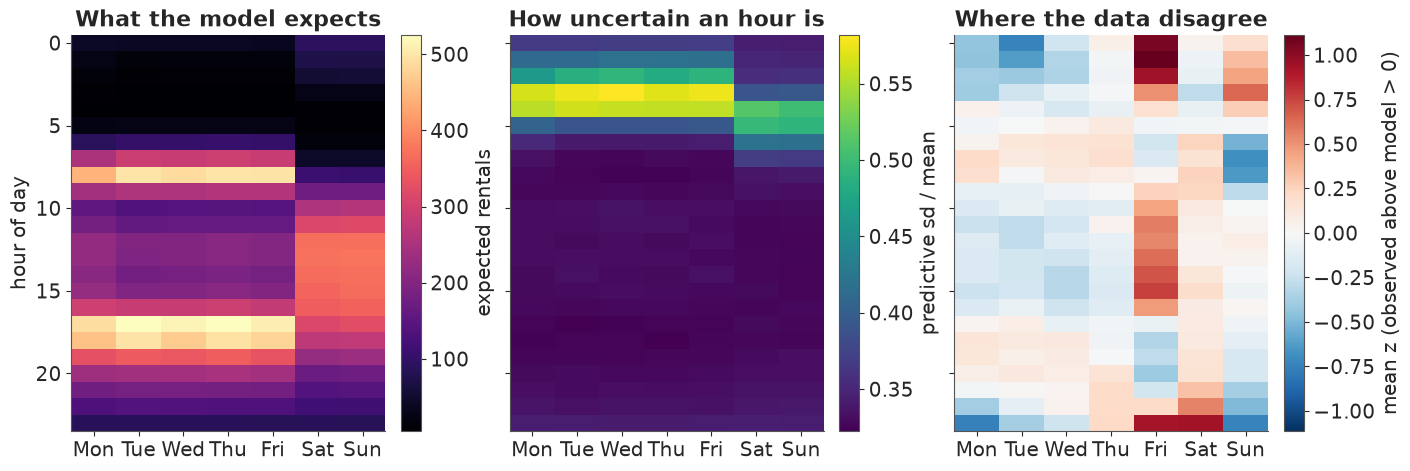

In [30]:
week = (
    xr.Dataset({"expected": yrep.mean("sample"), "cv": yrep.std("sample") / yrep.mean("sample"),
                "z": diag.z})
    .groupby("weekday").mean()
    .pipe(numeric_weekday)
)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
week.expected.plot(x="weekday", y="hour", ax=axes[0], cmap="magma", yincrease=False,
                   cbar_kwargs={"label": "expected rentals"})
week.cv.plot(x="weekday", y="hour", ax=axes[1], cmap="viridis", yincrease=False,
             cbar_kwargs={"label": "predictive sd / mean"})
week.z.plot(x="weekday", y="hour", ax=axes[2], cmap="RdBu_r", center=0, yincrease=False,
            cbar_kwargs={"label": "mean z (observed above model > 0)"})
for ax, title in zip(axes, ["What the model expects", "How uncertain an hour is",
                            "Where the data disagree"]):
    ax.set(title=title, xlabel="", ylabel="")
    ax.set_xticks(range(7), DOW)
axes[0].set_ylabel("hour of day");

The middle panel explains a NegBinomial fact: the predictive coefficient of variation is
about $\sqrt{1/\mu + 1/\alpha}$, so it is largest at 3-5 am when counts are tiny, and flattens
out near $1/\sqrt{\alpha} \approx 0.32$ whenever the counts are large. The right panel is the
interesting one: **Friday** is not an ordinary workday (more riders from late morning to
mid-afternoon, fewer in the evening rush), the small hours of Friday and Sunday and late
Saturday evening are busier than the profiles say, and Sunday morning and the last hours of
Sunday and Monday are quieter. Two day types are too few; a `weekday x hour` profile is the
obvious next model, and it would drop into the same code.

### A calendar of surprise

Finally, one PIT per **day** from the daily totals: near 0 means far fewer rentals than
the model expected for that date's weather and calendar, near 1 far more. To draw it as a
calendar we give each date a (year, week-of-year, weekday) label and reshape by those labels:
`set_index(date=[...])` turns them into a `MultiIndex` and `unstack` spreads it into three
dimensions. (ISO week numbers do not work here: 1 January 2011 is in ISO week 52 of 2010,
so (year, week, weekday) would repeat and `unstack` refuses duplicates.)

{'year': 2, 'week': 54, 'dow': 7}


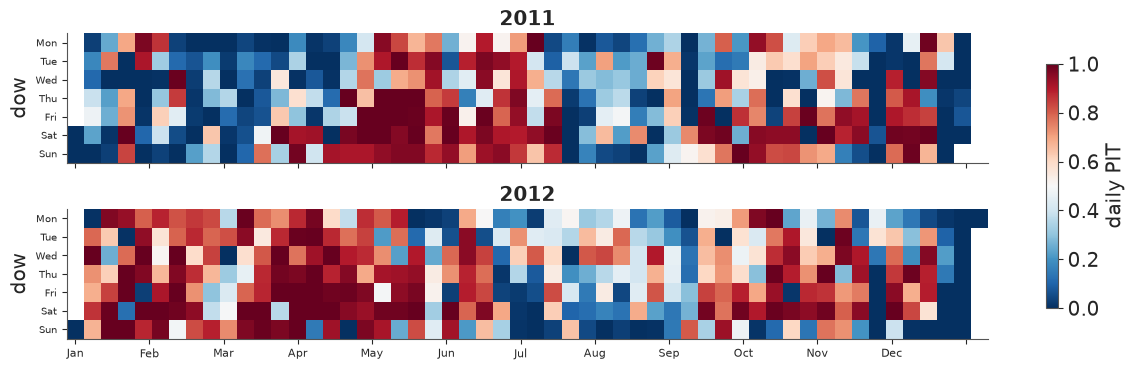

In [31]:
pit_day = (rep_day < obs_day).mean("sample") + 0.5 * (rep_day == obs_day).mean("sample")
d = pit_day.indexes["date"]
jan1 = pd.to_datetime(d.year.astype(str) + "-01-01")
cal = (
    pit_day.assign_coords(
        year=("date", d.year), dow=("date", d.dayofweek),
        week=("date", (d.dayofyear - 1 + jan1.dayofweek) // 7),
    )
    .drop_vars(["weekday", "workingday", "holiday", "daytype"])
    .set_index(date=["year", "week", "dow"])
    .unstack("date")
)
print(dict(cal.sizes))

fg = cal.plot(x="week", y="dow", row="year", cmap="RdBu_r", vmin=0, vmax=1, yincrease=False,
              size=2.1, aspect=5.5, cbar_kwargs={"label": "daily PIT", "shrink": 0.8})
for ax in fg.axs.flat:
    ax.set_yticks(range(7), DOW, fontsize=7)
    ax.set_xticks(np.arange(0, 53, 4.35), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul",
                                            "Aug", "Sep", "Oct", "Nov", "Dec", ""], fontsize=8)
    ax.set_xlabel("")
fg.set_titles("{value}");

If the model were calibrated at the daily level this would be salt-and-pepper noise with
10% of the days deep red or deep blue. Instead a third of all days fall outside their 90%
interval, and the colours come in **runs**: blue in January-February and July-August 2011,
red through the first five months of 2012, blue again in its summer, dark blue over both
Christmas weeks. A shock shared by all
the hours of a day - and often by neighbouring days - is exactly what the hourly model
lacks.

`.where(..., drop=True)` pulls out the most surprising days as a short list, keeping their
coords (weekday, holiday) attached:

In [32]:
outside = (pit_day < 0.05) | (pit_day > 0.95)
print(f"days outside the 90% predictive interval: {float(outside.mean()):.0%} (should be 10%)")

ratio_day = (obs_day / rep_day.mean("sample")).rename("observed / expected")
surprise = ratio_day.where((ratio_day < 0.5) | (ratio_day > 1.5), drop=True)
surprise.to_dataframe()[["weekday", "holiday", "observed / expected"]].round(2)

days outside the 90% predictive interval: 34% (should be 10%)


,weekday,holiday,observed / expected
date,,,
2011-01-01,Sat,0,0.46
2011-01-02,Sun,0,0.46
2011-03-06,Sun,0,0.33
2011-03-10,Thu,0,0.35
2011-04-16,Sat,0,0.38
2011-04-30,Sat,0,1.50
2011-08-27,Sat,0,0.45
2011-10-29,Sat,0,0.48
2011-11-24,Thu,1,0.40


The biggest misses are recognisable: the Christmas-New Year weeks, Thanksgiving (24 November
2011, 22 November 2012), 1-2 January 2011 and 27 August 2011 as Hurricane Irene arrived.
Hurricane Sandy (29-30 October 2012) is *not* on the list: the hours when the system was shut
have no record, and `yrep` is masked at exactly the same hours, so the daily totals compare
like with like. That is a choice to be aware of - a masked comparison cannot see an outage.

## 7 · Fixing the day-level misfit, and predicting new days by broadcasting

The calendar says the missing piece is a shock shared by all hours of a day (a holiday
week, a storm the hourly weather code under-rates, an event in town). The smallest fix is a
day-level effect. We write it **hierarchically centred**: each date gets a level whose mean is
the day-level part of the old predictor,

$$
\ell_d \sim \text{Normal}(a_{k(d)} + \tau t_d,\ \sigma_{\text{day}}), \qquad
\log \mu_{dh} = \ell_d + \text{profile}_{k,h} + \beta_k T_{dh} + \gamma_k T_{dh}^2
    + w_{\text{weather}_{dh}}
$$

A zero-mean day effect *added* to $a + \tau t$ gave a ridge between the intercept, the trend
and the 731 day effects (min bulk ESS about 170, r_hat 1.02-1.03, even with 1000 tuning
steps or a sum-to-zero day effect); centring the level on them removes the ridge. The model
gets one new dimension, `date`, and its coordinate is the actual `DatetimeIndex`.

In [33]:
date_idx = ds.indexes["date"].get_indexer(rows.date.values)
daytype_of_date = pd.Index(DAYTYPES).get_indexer(ds.daytype.values)

with pm.Model(coords=coords | {"date": ds.indexes["date"]}) as model_day:
    a = pm.Normal("a", 5, 1.5, dims="daytype")
    profile = pm.ZeroSumNormal("profile", sigma=1.5, dims=("daytype", "hour"), n_zerosum_axes=1)
    b_temp = pm.Normal("b_temp", 0, 0.5, dims="daytype")
    b_temp2 = pm.Normal("b_temp2", 0, 0.5, dims="daytype")
    weather_eff = pm.ZeroSumNormal("weather_eff", sigma=0.5, dims="weather")
    trend = pm.Normal("trend", 0, 0.5)
    alpha = pm.Gamma("alpha", 2, 0.2)
    sigma_day = pm.HalfNormal("sigma_day", 0.5)
    day_level = pm.Normal(
        "day_level", a[daytype_of_date] + trend * ds.t_years.values, sigma_day, dims="date"
    )
    eta = (
        day_level[date_idx] + profile[daytype_idx, rows.hour.values]
        + b_temp[daytype_idx] * T_rows + b_temp2[daytype_idx] * T_rows**2
        + weather_eff[weather_idx]
    )
    pm.NegativeBinomial(
        "cnt", mu=pm.math.exp(eta), alpha=alpha, observed=rows.cnt.values.astype(int), dims="obs"
    )
    idata_day = pm.sample(random_seed=RANDOM_SEED)

summ_day = az.summary(idata_day, round_to=4)
print(
    f"max r_hat {summ_day.r_hat.max():.3f}, min bulk ESS {summ_day.ess_bulk.min():.0f}, "
    f"min tail ESS {summ_day.ess_tail.min():.0f}, "
    f"divergences {int(idata_day.sample_stats['diverging'].sum())}"
)
summ_day.loc[["sigma_day", "alpha", "trend", "b_temp[workday]", "b_temp[off day]"]]

NUTS[nutpie]: [a, profile, b_temp, b_temp2, weather_eff, trend, alpha, sigma_day, day_level]


max r_hat 1.010, min bulk ESS 446, min tail ESS 640, divergences 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_day,0.2406,0.0069,0.2298,0.2517,4314.9999,3025.3367,1.0014,0.0001,0.0001
alpha,17.0989,0.2462,16.6962,17.4882,5743.9133,2943.2002,1.0005,0.0033,0.0043
trend,0.4540,0.0160,0.4281,0.4795,1389.9367,2274.1961,1.0010,0.0004,0.0002
b_temp[workday],0.2848,0.0096,0.2694,0.2995,470.0029,805.3878,1.0104,0.0004,0.0002
b_temp[off day],0.4012,0.0137,0.3798,0.4235,445.7970,640.2276,1.0074,0.0007,0.0003


Sampling is still clean (r_hat at most 1.01, bulk ESS at least ~450 - lowest for the
temperature slopes, since temperature is mostly a day-level covariate and still trades off
with the day levels - and no divergences). A typical day now sits a factor of about
$e^{0.24} \approx 1.27$ above or below what its calendar and weather predict, and the
NegBinomial $\alpha$ rose from about 10 to 17: much of what model 1 called hour-to-hour
overdispersion was day-to-day variation.

**Predicting a day the model has not seen.** `pm.sample_posterior_predictive` would reuse
each date's *fitted* level - fine for checking the fit, but the planner's question is "how
uncertain is next July?", where the level is not known in advance. So we draw a **new** level
for every date and every posterior draw, then assemble the mean function on the full
`date x hour` grid. Two idioms do all the work:

- **vectorised selection by label**: `post["a"].sel(daytype=ds.daytype)` looks up each
  date's day type and returns an array over `date` - the named version of `a[daytype_idx]`.
  With a 2-D indexer (`ds.weather` is `date x hour`) the result is 2-D;
- broadcasting: the fresh noise has dims `(sample, date)`, the profile `(sample, date, hour)`,
  and `+` lines them up.

In [34]:
post_day = az.extract(idata_day.isel(draw=slice(None, None, 10)))  # the same 400 draws
eps = xr.DataArray(
    rng.standard_normal((post_day.sizes["sample"], ds.sizes["date"])),
    dims=("sample", "date"), coords={"date": ds.indexes["date"]},
)  # no sample index: it aligns with post_day's sample by position
new_level = (post_day["a"].sel(daytype=ds.daytype) + post_day["trend"] * ds.t_years
             + post_day["sigma_day"] * eps)

T_grid = (ds.temp_c - 15) / 10  # NaN where there is no record
by_type = post_day[["profile", "b_temp", "b_temp2"]].sel(daytype=ds.daytype)
mu_new = np.exp(
    new_level + by_type["profile"] + by_type["b_temp"] * T_grid + by_type["b_temp2"] * T_grid**2
    + post_day["weather_eff"].sel(weather=ds.weather.fillna("clear"))
)
p_nb = (post_day["alpha"] / (post_day["alpha"] + mu_new)).fillna(1.0)  # p = 1: zero draws
ynew = (xr.apply_ufunc(rng.negative_binomial, post_day["alpha"], p_nb)
        .where(ds.cnt.notnull()).transpose("sample", "date", "hour"))
new_day = ynew.sum("hour")
print(dict(ynew.sizes))
del mu_new, p_nb, by_type

{'sample': 400, 'date': 731, 'hour': 24}


Now compare the two models' predictive coverage at three time scales. `xr.concat` along a
**new named dimension** (`pd.Index([...], name="model")`) stacks the two sets of daily draws,
so every later step - `resample`, `quantile`, the coverage test - runs for both models at once
and the result is labelled by model.

In [35]:
both = xr.concat(
    [r.drop_vars(["chain", "draw", "sample"]) for r in (rep_day, new_day)],
    dim=pd.Index(["no day effect", "day effect (new days)"], name="model"),
)


def coverage(rep: xr.DataArray, obs: xr.DataArray, prob: float = 0.9) -> xr.DataArray:
    """Share of time points whose observation falls inside the central `prob` interval."""
    q = rep.quantile([(1 - prob) / 2, (1 + prob) / 2], dim="sample")
    return ((obs >= q.isel(quantile=0)) & (obs <= q.isel(quantile=1))).mean("date")


cov = xr.Dataset({
    "day": coverage(both, obs_day),
    "week": coverage(both.resample(date="W").sum(), obs_day.resample(date="W").sum()),
    "month": coverage(both.resample(date="MS").sum(), obs_day.resample(date="MS").sum()),
})
cov.to_pandas().round(2)

,day,week,month
model,,,
no day effect,0.65,0.36,0.25
day effect (new days),0.94,0.75,0.58


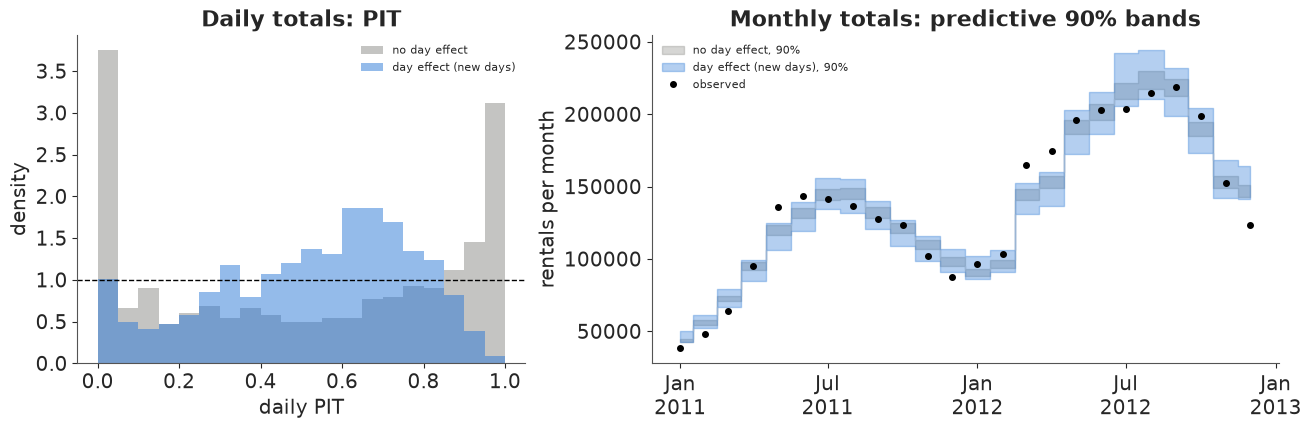

In [36]:
pit_both = (both < obs_day).mean("sample") + 0.5 * (both == obs_day).mean("sample")
fan_both = both.resample(date="MS").sum().quantile([0.05, 0.5, 0.95], dim="sample")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), width_ratios=[1, 1.4])
for model_name, color in zip(both.model.values, [GREY, BLUE]):
    axes[0].hist(pit_both.sel(model=model_name), bins=20, range=(0, 1), density=True,
                 histtype="stepfilled", alpha=0.5, color=color, label=model_name)
    f = fan_both.sel(model=model_name)
    axes[1].fill_between(f.date, f.sel(quantile=0.05), f.sel(quantile=0.95), color=color,
                         alpha=0.35, step="mid", label=f"{model_name}, 90%")
axes[0].axhline(1, color="k", ls="--", lw=1)
axes[0].set(xlabel="daily PIT", ylabel="density", title="Daily totals: PIT")
axes[0].legend(fontsize=8)
axes[1].plot(obs_month.date, obs_month, "o", color="k", ms=4, label="observed")
axes[1].set(ylabel="rentals per month", title="Monthly totals: predictive 90% bands")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[1].legend(loc="upper left", fontsize=8);

The daily PIT is no longer U-shaped, and daily coverage goes from 65% to 94% (now slightly
too wide; the day levels also soak up the Friday and weather-by-hour misfits of section 6).
Weekly and monthly coverage improve a lot (36% -> 75%, 25% -> 58%) but stay below 90%:
independent day levels still average out over a month, while the calendar showed errors
that persist for weeks. The xarray code does not care which model produced the draws - which
is the point: once predictions are labelled arrays, checking a new model at every time scale
is a re-run, not a rewrite.

## 8 · The idioms on one page

| Task | Named (this notebook) | Instead of |
|---|---|---|
| table -> grid | `df.set_index([...]).to_xarray()` | pivot tables and position bookkeeping |
| per-day attributes | `assign_coords(weekday=("date", ...))` | parallel arrays you must keep in sync |
| grid -> model rows -> grid | `stack(obs=...)`, `dropna`, `assign_coords(MultiIndex)`, `unstack` | index arithmetic |
| pick a slice | `.sel(daytype="workday", hour=8)` | `x[:, :, 0, 8]` |
| thin everything | `idata.isel(draw=slice(None, None, 10))` | thinning each group separately |
| chains -> samples | `az.extract(idata)`, `.unstack("sample")` | `reshape(-1, ...)` |
| scenario grid | arithmetic on `DataArray`s with new dims | `np.newaxis` / `reshape` / loops |
| NumPy function on labelled data | `xr.apply_ufunc(f, *args)` | unpack, call, re-wrap |
| calendar totals | `.resample(date="W"/"MS").sum()` on draws, then `.quantile` | summing quantiles |
| rolling / blocks / running total | `.rolling(date=7)`, `.coarsen(date=7)`, `.cumulative("date").sum()` | convolution by hand |
| binning | `groupby(x=BinGrouper(bins, labels))`, `groupby_bins` | `np.digitize` + masks |
| cross-tabs | `groupby(hour=BinGrouper(...), weather=UniqueGrouper())` | nested loops |
| reshape by labels | `set_index(date=[...]).unstack("date")` | building a 3-D array by hand |
| per-row parameter lookup | `post["a"].sel(daytype=ds.daytype)` (vectorised `.sel`) | `a[:, idx]` |
| compare models / scenarios | `xr.concat([...], dim=pd.Index([...], name="model"))` | parallel variables |

## Try it yourself

1. **Correlated days.** Holiday weeks and wet spells last several days, but the day levels
   of section 7 are independent. Give them an AR(1) over `date` (`pm.AR`), redo the new-day
   predictive, and check the *weekly* and *monthly* coverage: does it approach 90%?
2. **Riders as a dimension.** `casual` and `registered` riders behave very differently.
   Build `ds[["casual", "registered"]].to_dataarray("rider")`, fit the model with a `rider`
   dim on the profile and temperature effects, and facet every figure with `col="rider"`.
3. **A warmer year.** Shift every hour's temperature by +2 °C (`ds.temp_c + 2`), evaluate the
   posterior mean function on the actual 2012 calendar by broadcasting, and give the change
   in monthly totals as a fan chart. Which months gain, and which lose?